<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Deep_Fake_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
from datasets import load_dataset

In [3]:
from google.colab import userdata

In [4]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [5]:
dataset = load_dataset("thenewsupercell/celeb-df-image-dataset")

README.md:   0%|          | 0.00/620 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  310MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  309MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/73660 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9975 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10165 [00:00<?, ? examples/s]

In [6]:
dataset.shape

{'train': (73660, 2), 'validation': (9975, 2), 'test': (10165, 2)}

In [7]:
import collections

# Select the 'train' split from the DatasetDict
train_dataset = dataset['train']

# Get the list of string labels for all samples in the 'train' split
label_strings = train_dataset.features['label'].int2str(train_dataset['label'])

# Get the actual names of the labels as defined in the dataset
available_label_names = train_dataset.features['label'].names
print(f"Available label names in dataset: {available_label_names}")

# Count occurrences of each label string
label_counts_dict = collections.Counter(label_strings)

print("\nSample counts per label:")
for label_name, count in label_counts_dict.items():
    print(f"  {label_name} samples: {count}")

Available label names in dataset: ['Fake', 'Real']

Sample counts per label:
  Fake samples: 72910
  Real samples: 750


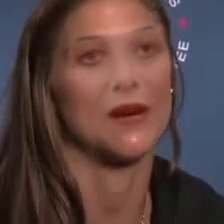

In [8]:
display(dataset['train'][0]['image'])

In [9]:
!pip install torch
!pip install --upgrade transformers
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 109.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [10]:
import torch
import evaluate
import numpy as np
from transformers import (ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer)
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
from torchvision.datasets import ImageFolder

# Initialize the image processor for the ViT model
# This ensures 'image_processor' is defined before being used.
image_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [11]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Define the transformations
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class HuggingFaceImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform
        # Create a mapping from label names (strings) to integers if not already present
        self.label_map = {name: i for i, name in enumerate(hf_dataset.features['label'].names)}

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'] # Assumes 'image' column contains PIL Image objects

        # Convert label from integer to string and then map to integer again if necessary
        # This ensures consistency even if the original label is already an integer
        label_name = self.hf_dataset.features['label'].int2str(item['label'])
        label = self.label_map[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

# Instantiate the custom dataset for each split
train_dataset = HuggingFaceImageDataset(dataset['train'], transform=transform)
val_dataset = HuggingFaceImageDataset(dataset['validation'], transform=transform)
test_dataset = HuggingFaceImageDataset(dataset['test'], transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Batch Count (train):", len(train_loader))
print("Batch Count (validation):", len(val_loader))
print("Batch Count (test):", len(test_loader))


Batch Count (train): 2302
Batch Count (validation): 312
Batch Count (test): 318


In [12]:
def transform(example_batch):
  inputs = image_processor([x.convert("RGB") for x in example_batch["image"]], return_tensors="pt")
  inputs["labels"] = example_batch["label"]
  return inputs

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def collate_fn(batch):
  return{
      "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
      "labels": torch.tensor([x["labels"] for x in batch])
  }

metric = evaluate.load("accuracy")

def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    accuracy = accuracy_score(labels, predictions)
    # Calculate precision, recall, f1-score for each class, using 'weighted' average to account for imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [24]:
from json import load
from transformers.trainer_utils import IntervalStrategy

training_args = TrainingArguments(
    output_dir="./vit-classifier-results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    #eval_steps="epoch",
    eval_strategy="steps",
    save_strategy="steps", # Changed to 'steps' to match eval_strategy
    learning_rate=5e-5,
    num_train_epochs=2, # Increased epochs to allow more training with weighted loss
    logging_steps=10,
    remove_unused_columns=False,
    metric_for_best_model="f1", # Changed metric_for_best_model to f1
    weight_decay=0.0001,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True, # Ensure this is True for EarlyStopping to load the best model
)

In [25]:
from transformers import EarlyStoppingCallback # Import EarlyStoppingCallback here
from sklearn.utils import class_weight
import torch.nn.functional as F
import torch # Import torch for device definition
from transformers import ViTForImageClassification, Trainer # Import Trainer here
from torch.utils.data import WeightedRandomSampler, DataLoader # Import DataLoader and WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create id2label and label2id mappings from available_label_names
id2label = {i: name for i, name in enumerate(available_label_names)}
label2id = {name: i for i, name in enumerate(available_label_names)}

# Re-initialize the model here to ensure the Trainer gets the correct ViTForImageClassification instance
# This addresses the TypeError by ensuring the Trainer has the model type it expects.
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224',
                                                  num_labels=len(available_label_names),
                                                  id2label=id2label,
                                                  label2id=label2id,
                                                  ignore_mismatched_sizes=True)
model = model.to(device);

splits = dataset["train"].train_test_split(test_size=0.2, seed=42)

# Apply the image processor transformation directly using the 'transform'.

train_hf_dataset = splits["train"].with_transform(transform)
eval_hf_dataset = splits["test"].with_transform(transform)

# --- Implement WeightedRandomSampler for balanced batches during training ---
# Calculate individual sample weights for WeightedRandomSampler
# Use splits["train"] directly to get original labels before any transformation
labels_for_sampler = np.array(splits["train"]["label"])
# Count occurrences of each class
class_counts = np.bincount(labels_for_sampler)

# Calculate inverse class frequency weights
class_weights_for_sampler = 1. / class_counts
sample_weights = torch.from_numpy(class_weights_for_sampler[labels_for_sampler]).double()


# Create the WeightedRandomSampler instance here
train_sampler = WeightedRandomSampler(sample_weights,  num_samples=10000, replacement=True)
# --- End of WeightedRandomSampler setup ---

# Define a custom Trainer to use weighted CrossEntropyLoss and WeightedRandomSampler
class CustomTrainer(Trainer):
    def get_train_dataloader(self):
        # Use the pre-created train_sampler
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=train_sampler, # Use the pre-defined sampler
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

# Define the EarlyStoppingCallback
early_stopping_callback = EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.001)

trainer = CustomTrainer( # Use CustomTrainer instead of Trainer
    model=model,
    args=training_args,
    train_dataset=train_hf_dataset, # Pass the Hugging Face dataset here
    eval_dataset=eval_hf_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback], # Pass the early stopping callback here
)

trainer.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
10,0.713955,0.660844,0.624627,0.505280,0.621556,0.399999
20,0.626945,0.453191,0.826907,0.513127,0.684689,0.482550
30,0.507653,0.462593,0.804032,0.516431,0.757767,0.480046
40,0.447131,0.640536,0.664404,0.513325,0.794646,0.424992
50,0.420253,0.263866,0.899335,0.539112,0.867763,0.546372
60,0.237042,0.429498,0.810005,0.523996,0.874716,0.493300
70,0.276004,0.226645,0.908770,0.548037,0.924613,0.563587
80,0.097196,0.116565,0.953095,0.581474,0.911200,0.626101
90,0.226003,0.042191,0.984659,0.688722,0.878318,0.750452
100,0.257540,0.063939,0.973595,0.630012,0.915046,0.693558


TrainOutput(global_step=170, training_loss=0.2853538800688351, metrics={'train_runtime': 952.3435, 'train_samples_per_second': 123.754, 'train_steps_per_second': 1.313, 'total_flos': 2.1077821175169024e+17, 'train_loss': 0.2853538800688351, 'epoch': 0.272})

### Evaluate on Validation Set

In [26]:
from sklearn.metrics import accuracy_score
import torch # Import torch for CrossEntropyLoss

model.eval() # Set the model to evaluation mode
val_loss = 0.0
all_preds = []
all_labels = []

criterion = torch.nn.CrossEntropyLoss() # Define the loss criterion

with torch.no_grad(): # Disable gradient calculations during evaluation
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs.logits, labels) # Access logits from the model output

        val_loss += loss.item()

        # Get predictions
        _, predicted = torch.max(outputs.logits.data, 1) # Access logits here too
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate average validation loss
avg_val_loss = val_loss / len(val_loader)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)

print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Loss: 0.1038
Validation Accuracy: 0.9667


In [27]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(all_labels, all_preds, target_names=available_label_names)
print("Classification Report on Validation Set:")
print(report)

Classification Report on Validation Set:
              precision    recall  f1-score   support

        Fake       1.00      0.97      0.98      9800
        Real       0.31      0.74      0.44       175

    accuracy                           0.97      9975
   macro avg       0.65      0.86      0.71      9975
weighted avg       0.98      0.97      0.97      9975



In [28]:
# Save the model and image processor
trainer.save_model("./best_deepfake_detector")
image_processor.save_pretrained("./best_deepfake_detector")
print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!
